<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  40.2MB/s    in 4.9s    

2026-08-25 07:32:05 (40.8 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]


#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)

   COUNT(*)
0     65437

**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


异常超大薪酬记录数：5367丢弃的天文脏数据数量：3772
保留用于绘图样本数量：29841

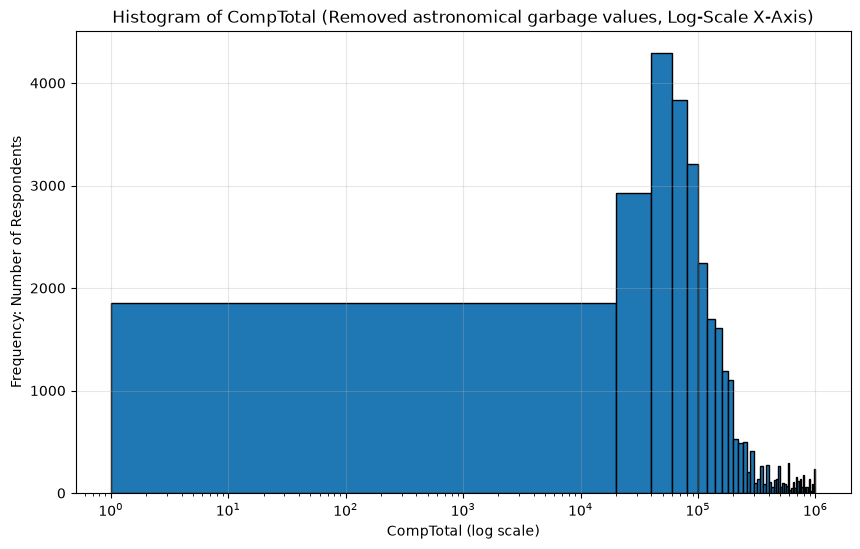

In [14]:
bad = df_comp[df_comp["CompTotal"]>600000]
print(f"异常超大薪酬记录数：{len(bad)}")

sql = """
SELECT CompTotal 
FROM main 
WHERE CompTotal IS NOT NULL AND CompTotal > 0
"""
df_comp = pd.read_sql_query(sql, conn)

df_filtered = df_comp[df_comp["CompTotal"] <= 1000000]
dropped = df_comp[df_comp["CompTotal"] > 1000000]
print(f"丢弃的天文脏数据数量：{len(dropped)}")
print(f"保留用于绘图样本数量：{len(df_filtered)}")

plt.figure(figsize=(10,6))
plt.hist(df_filtered["CompTotal"], bins=50, edgecolor="black")
plt.xscale("log")
plt.title("Histogram of CompTotal (Removed astronomical garbage values, Log‑Scale X‑Axis)")
plt.xlabel("CompTotal (log scale)")
plt.ylabel("Frequency: Number of Respondents")
plt.grid(alpha=0.3)
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


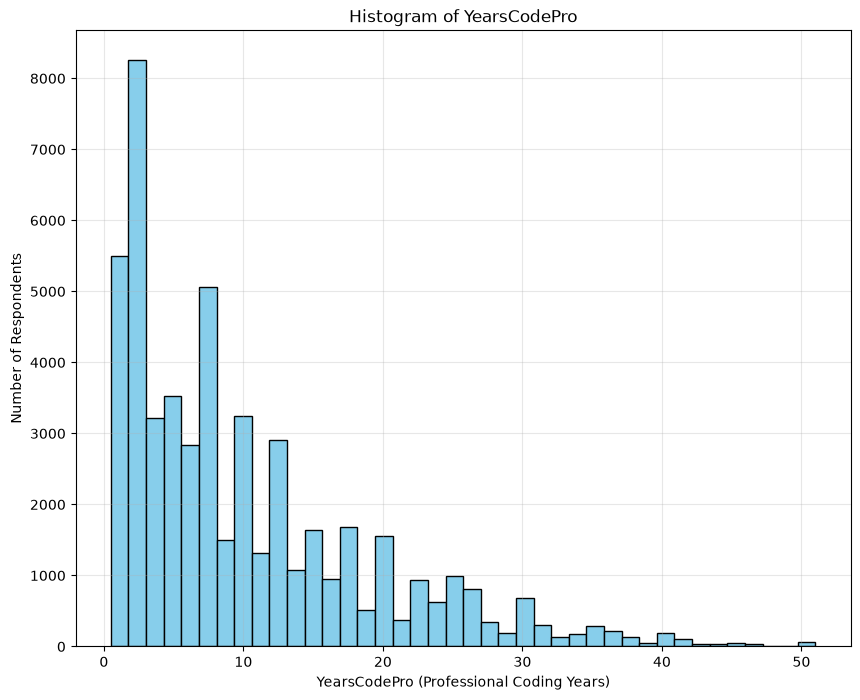

有效样本数量：51610

In [15]:
QUERY = "SELECT YearsCodePro FROM main"
df_pro = pd.read_sql_query(QUERY, conn)

def clean_pro_year(val):
    if val == "Less than 1 year":
        return 0.5
    elif val == "More than 50 years":
        return 51
    try:
        return float(val)
    except:
        return None

df_pro["cleaned"] = df_pro["YearsCodePro"].apply(clean_pro_year)
pro_data = df_pro["cleaned"].dropna()

plt.figure(figsize=(10,8))
plt.hist(pro_data, bins=40, color="skyblue", edgecolor="black")
plt.xlabel("YearsCodePro (Professional Coding Years)")
plt.ylabel("Number of Respondents")
plt.title("Histogram of YearsCodePro")
plt.grid(alpha=0.3)
plt.show()

print(f"有效样本数量：{len(pro_data)}")

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


<ArrowStringArray>
[   '25-34 years old',    '35-44 years old',    '45-54 years old',
    '55-64 years old',    '18-24 years old',  '65 years or older',
 'Under 18 years old']
Length: 7, dtype: str

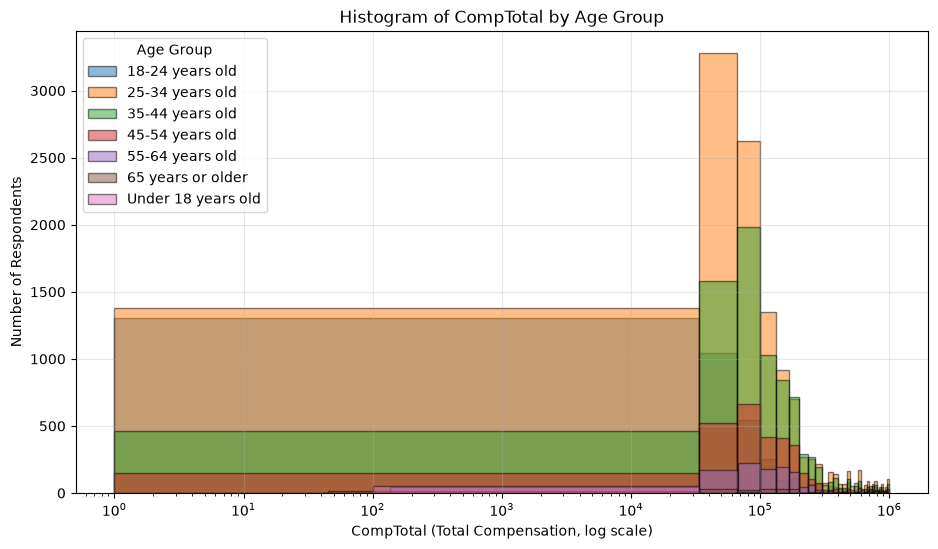

In [17]:
sql = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL 
AND CompTotal > 0 
AND CompTotal <= 1000000
AND Age IS NOT NULL
AND Age != 'Prefer not to say'
"""
df_age = pd.read_sql_query(sql, conn)

print(df_age["Age"].unique())

age_groups = [
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
    "Under 18 years old"
]

plt.figure(figsize=(11,6))
for group in age_groups:
    subset = df_age[df_age["Age"] == group]["CompTotal"]
    plt.hist(subset, bins=30, alpha=0.5, label=group, edgecolor="black")

plt.xscale("log")
plt.xlabel("CompTotal (Total Compensation, log scale)")
plt.ylabel("Number of Respondents")
plt.title("Histogram of CompTotal by Age Group")
plt.legend(title="Age Group")
plt.grid(alpha=0.3)
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


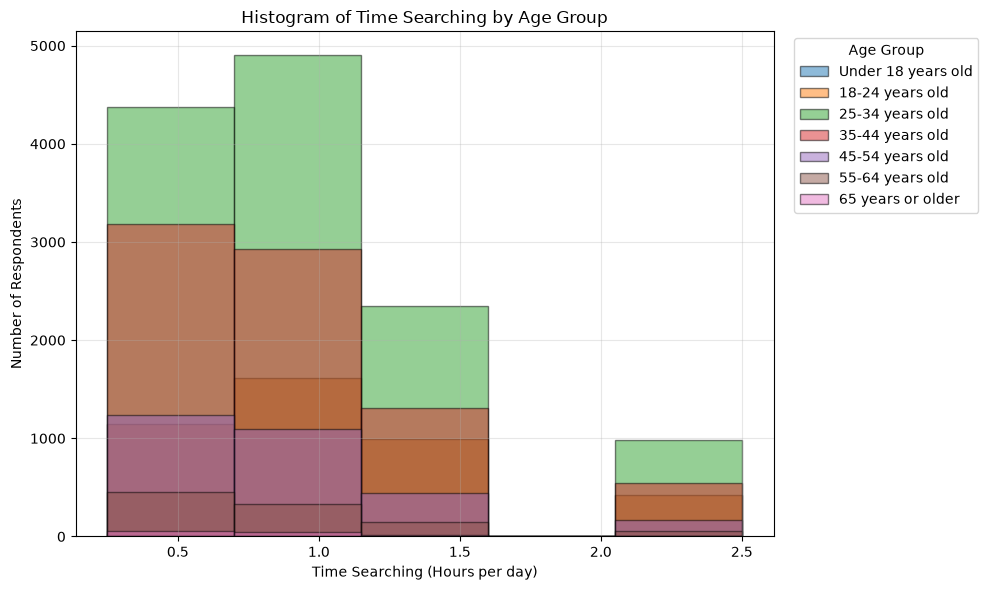

有效样本数量：28863

In [18]:
time_map = {
    "Less than 15 minutes a day": 0.25,  
    "15-30 minutes a day": 0.5, 
    "30-60 minutes a day": 0.75,
    "60-120 minutes a day": 1.5,  
    "Over 120 minutes a day": 2.5
}

QUERY = "SELECT Age, TimeSearching FROM main"
df_search = pd.read_sql_query(QUERY, conn)
df_search["TimeSearchingNum"] = df_search["TimeSearching"].map(time_map)

df_clean = df_search.dropna(subset=["Age", "TimeSearchingNum"])
df_clean = df_clean[df_clean["Age"] != "Prefer not to say"]

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

plt.figure(figsize=(10,6))
for age_group in age_order:
    subset = df_clean[df_clean["Age"] == age_group]["TimeSearchingNum"]
    if len(subset) > 0:
        plt.hist(subset, bins=5, alpha=0.5, label=age_group, edgecolor="black")

plt.xlabel("Time Searching (Hours per day)")
plt.ylabel("Number of Respondents")
plt.title("Histogram of Time Searching by Age Group")
plt.legend(title="Age Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"有效样本数量：{len(df_clean)}")

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


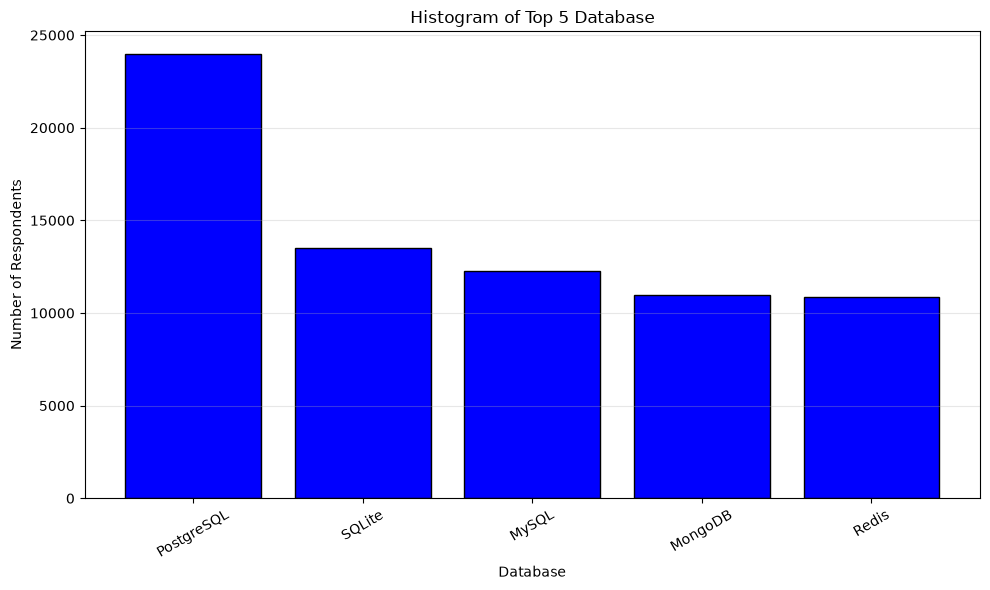

db_list
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

In [19]:
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_db = pd.read_sql_query(QUERY, conn)

df_db["db_list"] = df_db["DatabaseWantToWorkWith"].str.split(";")
df_exploded = df_db.explode("db_list")
df_exploded["db_list"] = df_exploded["db_list"].str.strip()

db_counts = df_exploded["db_list"].value_counts()
top5 = db_counts.head(5)

plt.figure(figsize=(10,6))
plt.bar(top5.index, top5.values, color="blue", edgecolor="black")
plt.xlabel("Database")
plt.ylabel("Number of Respondents")
plt.title("Histogram of Top 5 Database")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(top5)

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


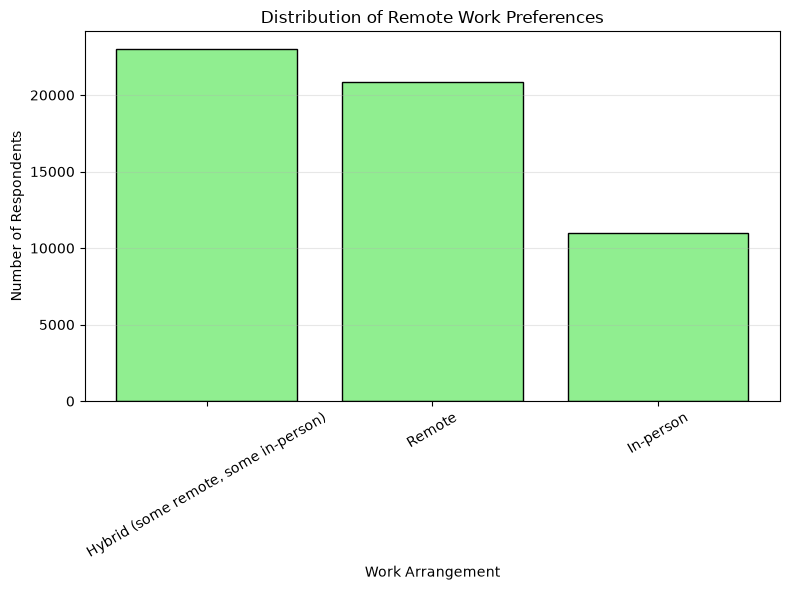

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

In [20]:
QUERY = "SELECT RemoteWork FROM main WHERE RemoteWork IS NOT NULL"
df_remote = pd.read_sql_query(QUERY, conn)
remote_counts = df_remote["RemoteWork"].value_counts()

plt.figure(figsize=(8,6))
plt.bar(remote_counts.index, remote_counts.values, color="lightgreen", edgecolor="black")
plt.title("Distribution of Remote Work Preferences")
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(remote_counts)

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


45‑60岁组薪酬中位数: 101910.00 USD
有效样本数：3184

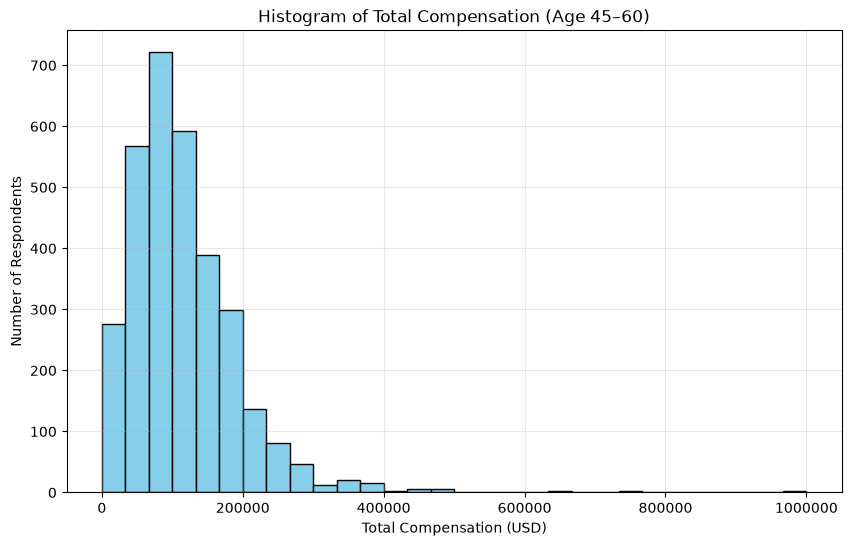

In [23]:
age_map = {
    "Under 18 years old":16,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

QUERY = "SELECT Age, ConvertedCompYearly FROM main"
df_comp = pd.read_sql_query(QUERY, conn)
df_comp["AgeNum"] = df_comp["Age"].map(age_map)
df_comp["ConvertedCompYearly"] = pd.to_numeric(df_comp["ConvertedCompYearly"], errors="coerce")

df_target = df_comp[
    (df_comp["AgeNum"] >= 45) & (df_comp["AgeNum"] <= 60)
    & (df_comp["ConvertedCompYearly"] > 0)
    & (df_comp["ConvertedCompYearly"] <= 1000000)
]
df_clean = df_target.dropna(subset=["ConvertedCompYearly"])

median_salary = df_clean["ConvertedCompYearly"].median()
print(f"45‑60岁组薪酬中位数: {median_salary:.2f} USD")
print(f"有效样本数：{len(df_clean)}")
plt.figure(figsize=(10,6))
plt.hist(df_clean["ConvertedCompYearly"], bins=30, color="skyblue", edgecolor="black")
plt.ticklabel_format(axis='x', style='plain')
plt.xlabel("Total Compensation (USD)")
plt.ylabel("Number of Respondents")
plt.title("Histogram of Total Compensation (Age 45–60)")
plt.grid(alpha=0.3)
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


有效绘图样本数：27568

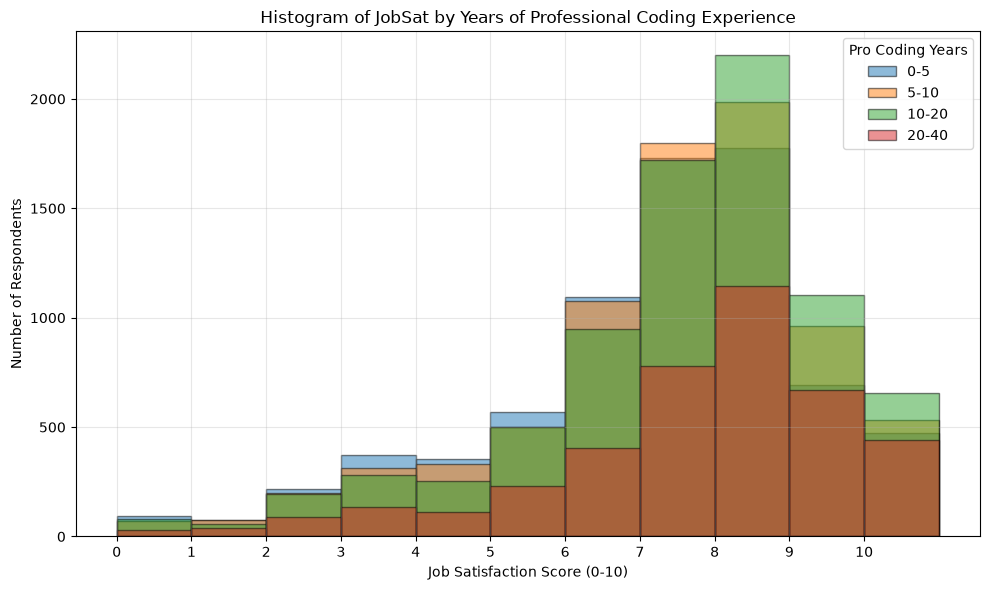

In [26]:
QUERY = "SELECT YearsCodePro, JobSat FROM main"
df_job = pd.read_sql_query(QUERY, conn)

df_job["YearsCodePro"] = pd.to_numeric(df_job["YearsCodePro"], errors="coerce")
df_job["JobSat"] = pd.to_numeric(df_job["JobSat"], errors="coerce")

df_clean = df_job.dropna(subset=["YearsCodePro", "JobSat"])

bins = [0, 5, 10, 20, 40]
labels = ["0‑5", "5‑10", "10‑20", "20‑40"]
df_clean["ExperienceRange"] = pd.cut(df_clean["YearsCodePro"], bins=bins, labels=labels, right=False)

print(f"有效绘图样本数：{len(df_clean)}")

plt.figure(figsize=(10,6))
for label in labels:
    subset = df_clean[df_clean["ExperienceRange"] == label]["JobSat"]
    if len(subset) > 0:
        plt.hist(subset, bins=range(0,12), alpha=0.5, label=label, edgecolor="black")

plt.xlabel("Job Satisfaction Score (0‑10)")
plt.ylabel("Number of Respondents")
plt.title("Histogram of JobSat by Years of Professional Coding Experience")
plt.legend(title="Pro Coding Years")
plt.grid(alpha=0.3)
plt.xticks(range(0,11))
plt.tight_layout()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [27]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
